# 🔏 Pengenalan Aksara Jawa 120 Kelas — Arsitektur VGG-16
Notebook ini melakukan transfer learning menggunakan PyTorch untuk mengklasifikasi 120 kelas silabik Aksara Jawa dari dataset Indonesian Local Script Characters.

### Alur Utama:
1. **Mempersiapkan Dataloader** dengan normalisasi ImageNet dan resize ke 224x224.
2. **Penerapan Class Weights** dari `output_pipeline/class_weights.json` ke Weighted CrossEntropyLoss.
3. **Fase 1 - Feature Extraction**: Melatih classifier head dengan parameter backbone dibekukan.
4. **Fase 2 - Full Fine-Tuning**: Melatih seluruh parameter jaringan secara end-to-end dengan learning rate lebih rendah.
5. **Evaluasi Akhir & Visualisasi**: Mengukur performa per kelompok Vokal A vs Vokal non-A serta visualisasi Confusion Matrix.


In [5]:
import os
import sys
import time
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Konfigurasi Path
OUTPUT_ROOT = Path("output_pipeline")
TRAIN_DIR = OUTPUT_ROOT / "augmented_train"
VAL_DIR = OUTPUT_ROOT / "split" / "val"
TEST_DIR = OUTPUT_ROOT / "split" / "test"
WEIGHTS_FILE = OUTPUT_ROOT / "class_weights.json"

RESULTS_DIR = Path("results_vgg_16")
MODEL_SAVE_PATH = RESULTS_DIR / "vgg_16_aksara_jawa_120class.pth"
HISTORY_SAVE_PATH = RESULTS_DIR / "training_history.json"
REPORT_SAVE_PATH = RESULTS_DIR / "evaluation_report.json"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥️ Device:", device)

# ============================================================
# HYPERPARAMETERS KHUSUS ARSITEKTUR VGG-16
# ============================================================
LR_PHASE1 = 5e-4
LR_PHASE2 = 2e-5
WEIGHT_DECAY = 1e-4
PATIENCE_ES = 15


🖥️ Device: cuda


## 📁 1. Memuat Dataset dan Preprocessing
Citra diubah menjadi grayscale lalu dikonversi ke 3-channel RGB agar cocok dengan pretrained model ImageNet, diikuti dengan normalisasi piksel standard.


In [6]:
img_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("📂 Memuat datasets...")
train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=img_transforms)
val_dataset = datasets.ImageFolder(root=str(VAL_DIR), transform=img_transforms)
test_dataset = datasets.ImageFolder(root=str(TEST_DIR), transform=img_transforms)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"   - Jumlah kelas : {num_classes}")
print(f"   - Training     : {len(train_dataset):,} citra")
print(f"   - Validasi     : {len(val_dataset):,} citra")
print(f"   - Testing      : {len(test_dataset):,} citra")

num_workers = 3
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=num_workers)


📂 Memuat datasets...
   - Jumlah kelas : 120
   - Training     : 38,510 citra
   - Validasi     : 1,789 citra
   - Testing      : 1,919 citra


## ⚖️ 2. Penyetelan Class Weights
Memuat hasil class weights dari pipeline untuk diumpankan ke loss function CrossEntropyLoss.


In [7]:
print(f"📖 Membaca bobot kelas dari: {WEIGHTS_FILE}")
with open(WEIGHTS_FILE, "r", encoding="utf-8") as f:
    meta = json.load(f)
class_to_idx = meta["class_to_idx"]
weight_dict = meta["class_weights"]

weight_tensor = torch.zeros(num_classes)
for cls_name, idx in class_to_idx.items():
    weight_tensor[idx] = weight_dict[cls_name]

class_weights = weight_tensor.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("✅ Class weights berhasil dimuat dan diterapkan ke loss function.")


📖 Membaca bobot kelas dari: output_pipeline\class_weights.json
✅ Class weights berhasil dimuat dan diterapkan ke loss function.


## 🏗️ 3. Inisialisasi Arsitektur VGG-16
Mengunduh bobot pretrained ImageNet dan menyesuaikan classifier head untuk 120 kelas Aksara Jawa.


In [8]:
print("🏗️ Memuat VGG-16 Pretrained...")
try:
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
except AttributeError:
    model = models.vgg16(pretrained=True)

# Ganti classifier head (linear di indeks 6 dari classifier)
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)
model = model.to(device)
print("✅ Model siap.")


🏗️ Memuat VGG-16 Pretrained...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ruhen/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [03:48<00:00, 2.42MB/s] 


✅ Model siap.


## 🛠️ 4. Definisi Helper Training (Epoch Loop, Eval, Early Stopping)
Menulis callback `EarlyStopping` dan fungsi standar epoch training.


In [9]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


## 🚀 5. FASE 1: FEATURE EXTRACTION (Melatih Kepala Klasifikasi saja)
Membekukan parameter *backbone* dan hanya melatih *classifier head* dengan learning rate $10^{-3}$ selama 10 epoch awal.


In [10]:
# Freeze backbone & Unfreeze classifier head (model-agnostic)
for param in model.parameters():
    param.requires_grad = False

if hasattr(model, 'classifier'):
    for param in model.classifier.parameters():
        param.requires_grad = True
    optimizer_fase1 = optim.Adam(model.classifier.parameters(), lr=LR_PHASE1, weight_decay=WEIGHT_DECAY)
elif hasattr(model, 'fc'):
    for param in model.fc.parameters():
        param.requires_grad = True
    optimizer_fase1 = optim.Adam(model.fc.parameters(), lr=LR_PHASE1, weight_decay=WEIGHT_DECAY)

epochs_phase1 = 10

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

print("🚀 Memulai Fase 1...")
for epoch in range(epochs_phase1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_fase1)
    val_loss, val_acc, val_f1 = evaluate_epoch(model, val_loader, criterion)
    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch [{epoch+1:02d}/{epochs_phase1:02d}] ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.2f}% - F1: {val_f1:.4f}")


🚀 Memulai Fase 1...
Epoch [01/10] (156.5s) | Train Loss: 2.3132 - Acc: 41.08% | Val Loss: 0.8762 - Acc: 74.51% - F1: 0.4583
Epoch [02/10] (152.0s) | Train Loss: 1.2811 - Acc: 67.78% | Val Loss: 0.6915 - Acc: 81.16% - F1: 0.5253
Epoch [03/10] (152.0s) | Train Loss: 1.1103 - Acc: 73.01% | Val Loss: 0.8272 - Acc: 77.42% - F1: 0.5027
Epoch [04/10] (151.7s) | Train Loss: 1.0521 - Acc: 74.97% | Val Loss: 0.7441 - Acc: 80.21% - F1: 0.5175
Epoch [05/10] (151.8s) | Train Loss: 1.0327 - Acc: 75.99% | Val Loss: 0.7277 - Acc: 80.44% - F1: 0.5062
Epoch [06/10] (151.7s) | Train Loss: 1.0360 - Acc: 76.53% | Val Loss: 0.8272 - Acc: 80.16% - F1: 0.5119
Epoch [07/10] (151.5s) | Train Loss: 1.0228 - Acc: 77.14% | Val Loss: 0.7617 - Acc: 80.32% - F1: 0.4900
Epoch [08/10] (151.7s) | Train Loss: 1.0126 - Acc: 77.33% | Val Loss: 0.7574 - Acc: 80.49% - F1: 0.5440
Epoch [09/10] (151.8s) | Train Loss: 1.0068 - Acc: 78.34% | Val Loss: 0.7728 - Acc: 80.38% - F1: 0.5182
Epoch [10/10] (152.9s) | Train Loss: 0.9962 

## 🚀 6. FASE 2: FULL FINE-TUNING (Melatih Seluruh Jaringan)
Membuka pembekuan parameter backbone untuk melatih seluruh jaringan secara end-to-end dengan learning rate yang lebih rendah ($10^{-4}$).


In [11]:
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

optimizer_fase2 = optim.Adam(model.parameters(), lr=LR_PHASE2, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fase2, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=PATIENCE_ES)
epochs_phase2 = 90
best_val_loss = float('inf')

print("🚀 Memulai Fase 2 (Fine-Tuning)...")
for epoch in range(epochs_phase2):
    actual_epoch = epochs_phase1 + epoch + 1
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_fase2)
    val_loss, val_acc, val_f1 = evaluate_epoch(model, val_loader, criterion)
    elapsed = time.time() - t0

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    curr_lr = optimizer_fase2.param_groups[0]['lr']
    print(f"Epoch [{actual_epoch:02d}/{epochs_phase1+epochs_phase2:02d}] ({elapsed:.1f}s) | LR: {curr_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.2f}% - F1: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), str(MODEL_SAVE_PATH))
        print(f"   💾 Checkpoint model terbaik disimpan ke: {MODEL_SAVE_PATH}")

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"🛑 EARLY STOPPING dipicu pada epoch {actual_epoch}!")
        break

# Simpan training history
with open(HISTORY_SAVE_PATH, "w") as f:
    json.dump(history, f, indent=2)


🚀 Memulai Fase 2 (Fine-Tuning)...
Epoch [11/100] (1473.9s) | LR: 2.00e-05 | Train Loss: 0.7052 - Acc: 83.73% | Val Loss: 0.4658 - Acc: 88.37% - F1: 0.6379
   💾 Checkpoint model terbaik disimpan ke: results_vgg_16\vgg_16_aksara_jawa_120class.pth
Epoch [12/100] (1473.5s) | LR: 2.00e-05 | Train Loss: 0.5781 - Acc: 86.46% | Val Loss: 0.3975 - Acc: 90.55% - F1: 0.7044
   💾 Checkpoint model terbaik disimpan ke: results_vgg_16\vgg_16_aksara_jawa_120class.pth
Epoch [13/100] (1472.1s) | LR: 2.00e-05 | Train Loss: 0.5247 - Acc: 87.71% | Val Loss: 0.3621 - Acc: 91.89% - F1: 0.7361
   💾 Checkpoint model terbaik disimpan ke: results_vgg_16\vgg_16_aksara_jawa_120class.pth
Epoch [14/100] (1472.2s) | LR: 2.00e-05 | Train Loss: 0.4892 - Acc: 88.64% | Val Loss: 0.3028 - Acc: 91.67% - F1: 0.7346
   💾 Checkpoint model terbaik disimpan ke: results_vgg_16\vgg_16_aksara_jawa_120class.pth
Epoch [15/100] (1473.8s) | LR: 2.00e-05 | Train Loss: 0.4480 - Acc: 89.39% | Val Loss: 0.3869 - Acc: 91.11% - F1: 0.7233
E

## 📊 7. Visualisasi Kurva Training
Menggambar kurva loss dan akurasi untuk memantau kemajuan model.


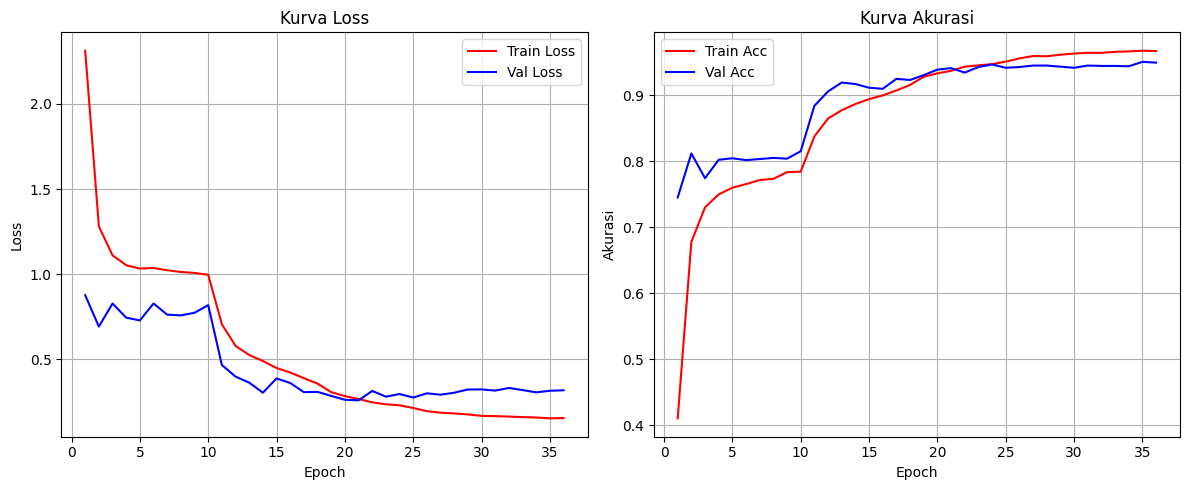

In [12]:
epochs_range = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], 'r-', label='Train Loss')
plt.plot(epochs_range, history["val_loss"], 'b-', label='Val Loss')
plt.title('Kurva Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], 'r-', label='Train Acc')
plt.plot(epochs_range, history["val_acc"], 'b-', label='Val Acc')
plt.title('Kurva Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()


## 🎯 8. Evaluasi Model pada Test Dataset (Kelompok Vokal A vs Vokal non-A)
Memuat parameter bobot terbaik yang disimpan, kemudian menguji pada data uji test set dan membagi metrik performa secara terpisah antara kelas Vokal A (mayoritas) dan Vokal non-A (minoritas).


In [13]:
print("💾 Memuat model terbaik untuk evaluasi test set...")
model.load_state_dict(torch.load(str(MODEL_SAVE_PATH)))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Identifikasi kelompok vokal
vokal_a_idx = [idx for name, idx in class_to_idx.items() if "vokal a_" in name.lower()]
vokal_a_indices = set(vokal_a_idx)

labels_a, preds_a = [], []
labels_non_a, preds_non_a = [], []

for l, p in zip(all_labels, all_preds):
    if l in vokal_a_indices:
        labels_a.append(l)
        preds_a.append(p)
    else:
        labels_non_a.append(l)
        preds_non_a.append(p)

f1_overall = f1_score(all_labels, all_preds, average='macro')
f1_a = f1_score(labels_a, preds_a, average='macro') if labels_a else 0.0
f1_non_a = f1_score(labels_non_a, preds_non_a, average='macro') if labels_non_a else 0.0
full_report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)

summary = {
    "overall_accuracy": full_report["accuracy"],
    "overall_macro_f1": f1_overall,
    "vokal_a_macro_f1": f1_a,
    "vokal_non_a_macro_f1": f1_non_a
}

with open(REPORT_SAVE_PATH, "w") as f:
    json.dump({"summary": summary, "full_report": full_report}, f, indent=2)

print("\n" + "="*60)
print("📊 LAPORAN EVALUASI AKHIR — VGG-16")
print("="*60)
print(f"  Akurasi Keseluruhan          : {summary['overall_accuracy']*100:.2f}%")
print(f"  Macro F1-Score Keseluruhan   : {summary['overall_macro_f1']:.4f}")
print("-"*60)
print(f"  F1-Score Kelompok Vokal A     (Mayoritas): {summary['vokal_a_macro_f1']:.4f}")
print(f"  F1-Score Kelompok Vokal non-A (Minoritas): {summary['vokal_non_a_macro_f1']:.4f}")
print("="*60)
print(f"Laporan tersimpan di: {REPORT_SAVE_PATH}")


💾 Memuat model terbaik untuk evaluasi test set...

📊 LAPORAN EVALUASI AKHIR — VGG-16
  Akurasi Keseluruhan          : 93.38%
  Macro F1-Score Keseluruhan   : 0.7867
------------------------------------------------------------
  F1-Score Kelompok Vokal A     (Mayoritas): 0.9824
  F1-Score Kelompok Vokal non-A (Minoritas): 0.7402
Laporan tersimpan di: results_vgg_16\evaluation_report.json


## 🎨 9. Visualisasi Confusion Matrix
Menampilkan visualisasi persebaran prediksi yang benar dan kesalahan klasifikasi.


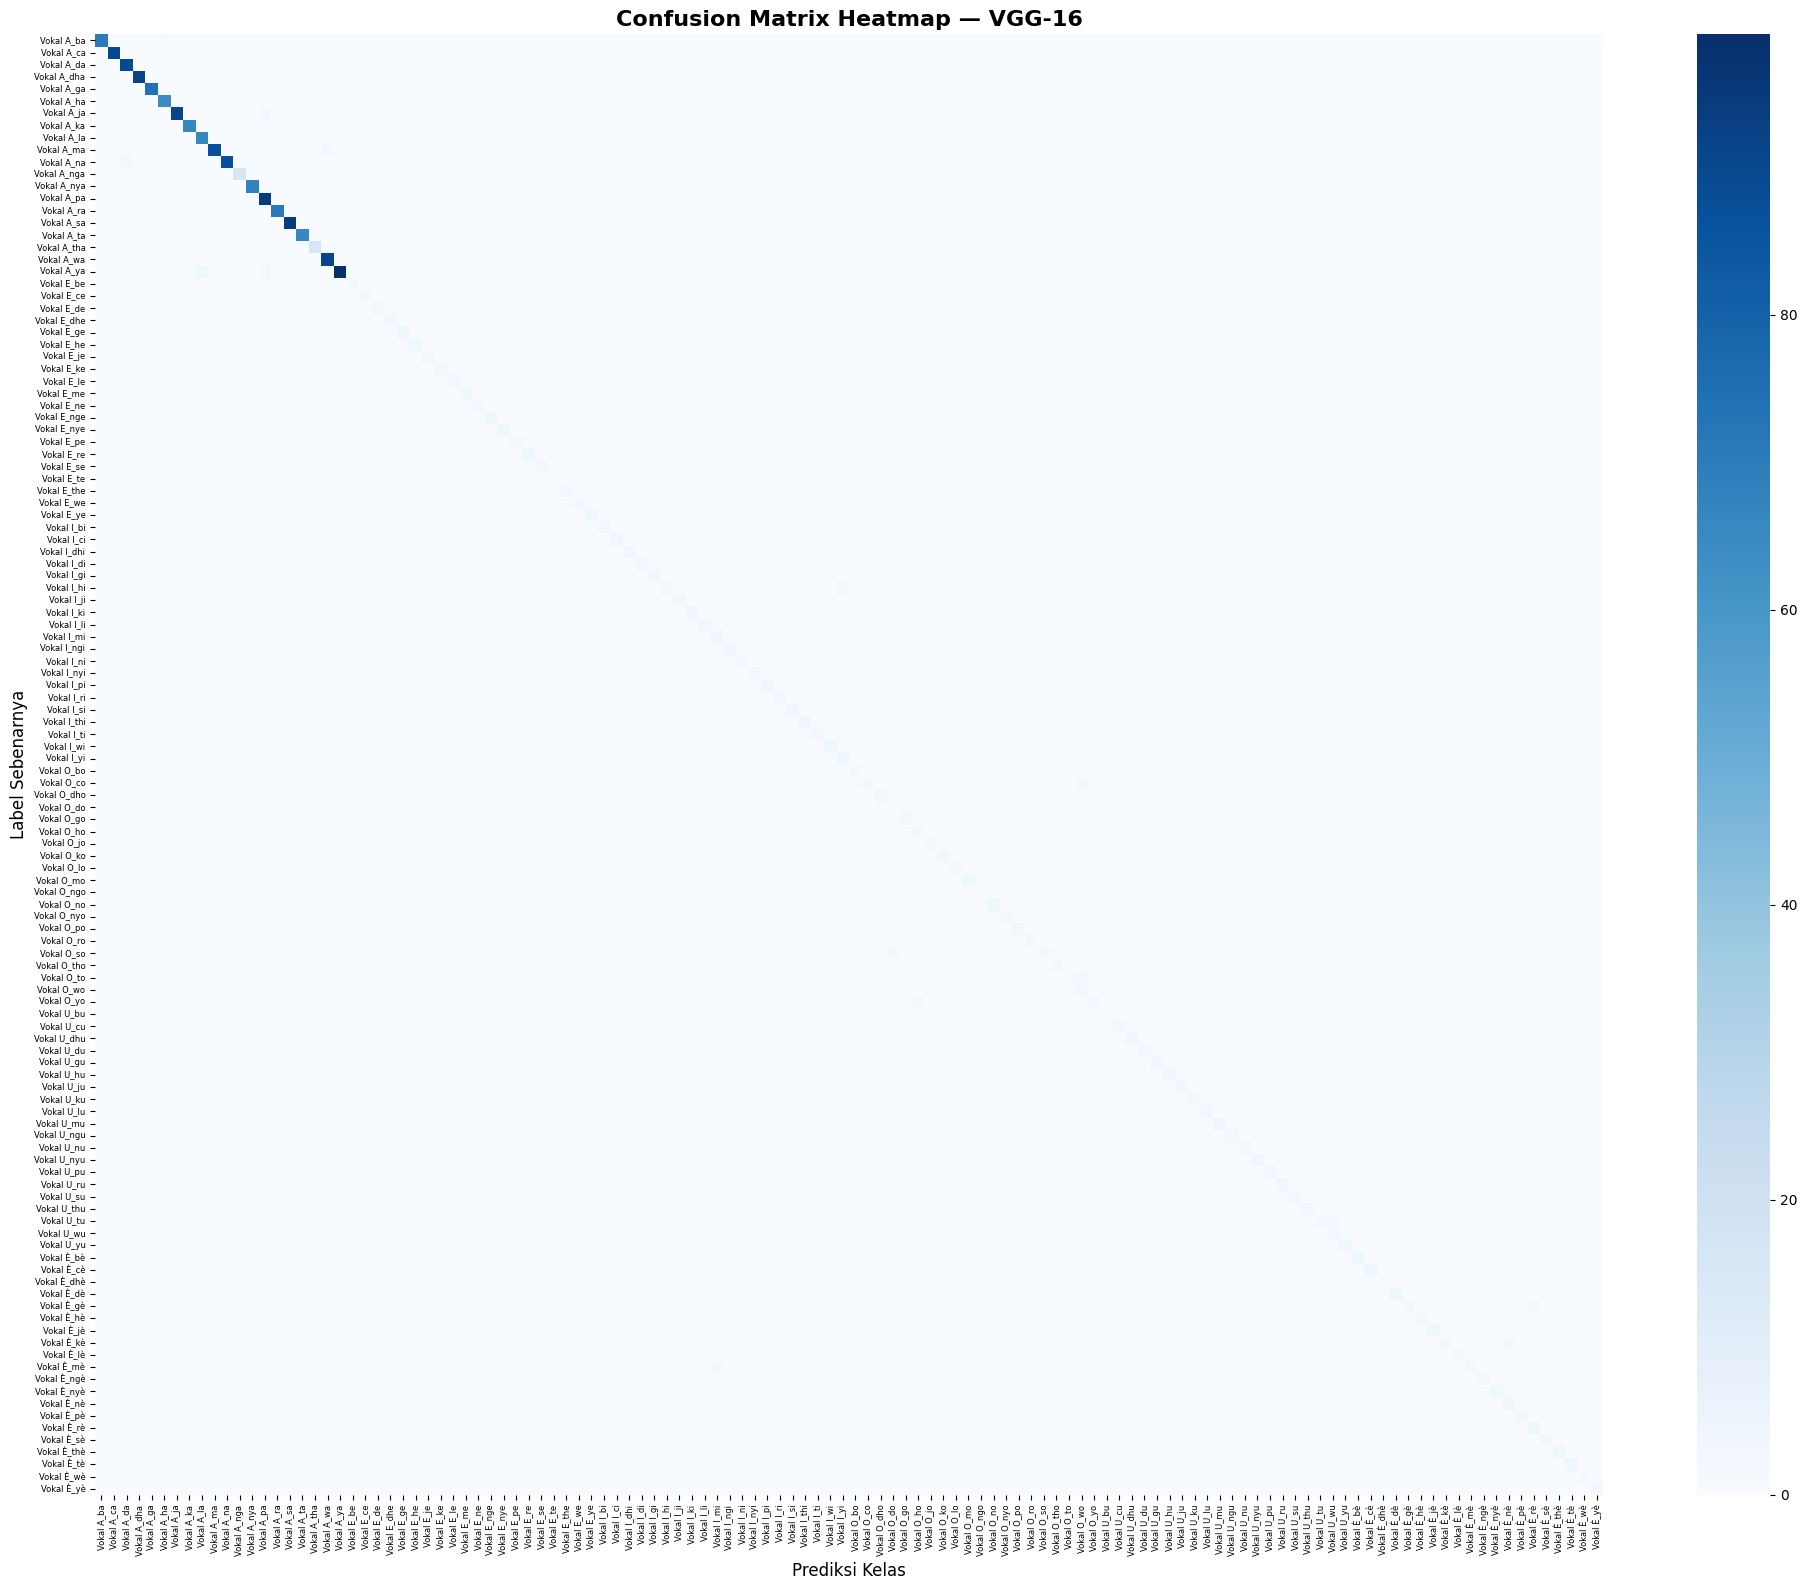

In [14]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Heatmap — VGG-16', fontsize=16, fontweight='bold')
plt.xlabel('Prediksi Kelas', fontsize=12)
plt.ylabel('Label Sebenarnya', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()
